# This notebook will create phantom and clinical US masks based on edge detection #

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

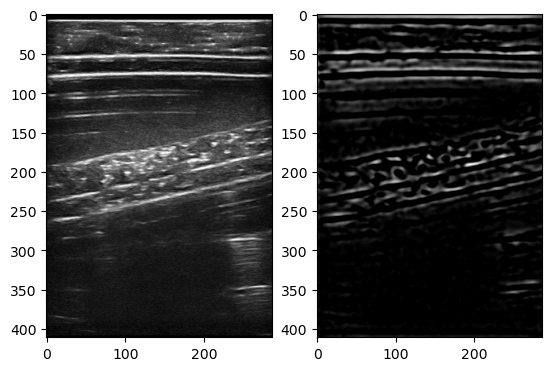

In [62]:
def LoG_filter_opencv(image, sigma, size=None):
    # Generate LoG kernel
    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1

    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))

    # Perform convolution using OpenCV filter2D
    result = cv2.filter2D(image, -1, kernel)

    return result

plt.subplot(1, 2, 1)
image = cv2.imread('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg', cv2.IMREAD_GRAYSCALE) 
plt.imshow(image,cmap='gray')
sigma = 3
filtered_image = LoG_filter_opencv(image, sigma)
filtered_image = cv2.convertScaleAbs(filtered_image)

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.show()

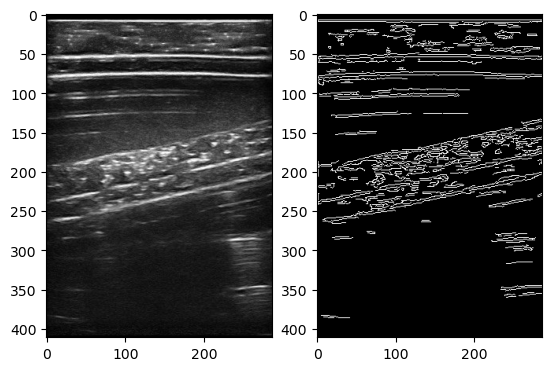

In [21]:
plt.subplot(1, 2, 1)
image = cv2.imread('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image,cmap='gray')

#canny edge detection
edges = cv2.Canny(image, threshold1=100, threshold2=300)

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.show()

before process 123.50514705882352
after process 122.61096885813149


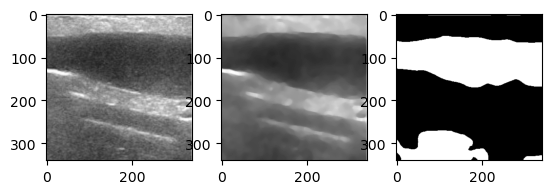

before process 125.0421381362677
after process 124.72220492058548


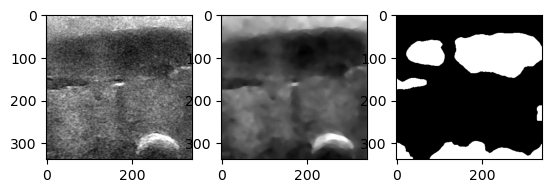

before process 70.3415750915751
after process 91.24741124260355


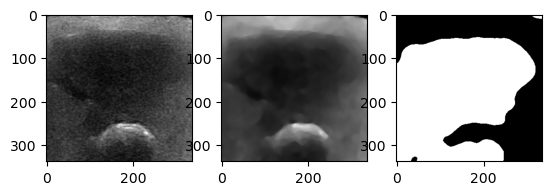

before process 89.15087546076883
after process 113.16772643496577


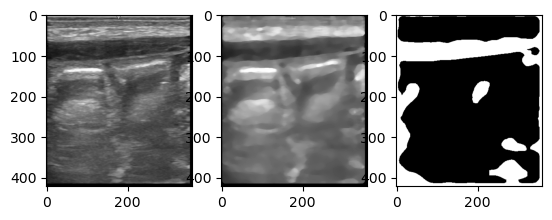

before process 67.23672472948007
after process 85.01667986276063


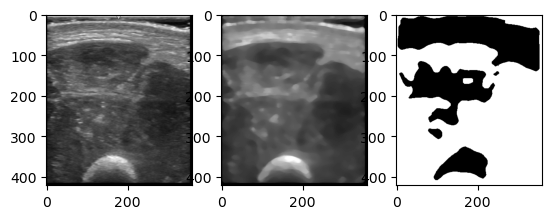

before process 70.8544451293771
after process 90.00875794981282


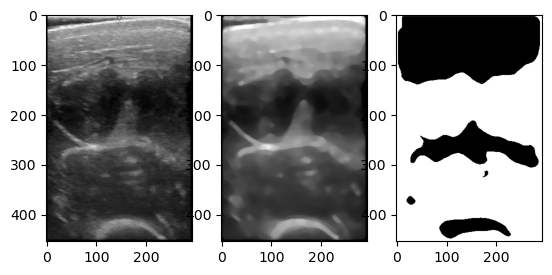

In [3]:
import cv2
import numpy as np

def mask(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    original = image
    if image is None:
        print("Error: Image not loaded. Check the path.")
        return
    mean_intensity = np.mean(image)
    print('before process',mean_intensity)

    if mean_intensity<110:
        image = cv2.convertScaleAbs(image, 35.3, 1.3)
        image = cv2.bilateralFilter(image,19,15,15)
        _, mask = cv2.threshold(image, 90, 255, cv2.THRESH_BINARY_INV)
        image = cv2.medianBlur(image,11)
        
        kernel = np.ones((3,3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  #remove noise
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) #close small holes
        mask = cv2.medianBlur(mask,21)
        mask = cv2.filter2D(mask, ddepth=-1, kernel=kernel)
    else:
        image = cv2.convertScaleAbs(image, 55.3, 1)
        image = cv2.bilateralFilter(image,19,15,15)
        _, mask = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY_INV)
        image = cv2.medianBlur(image,11)
        
        kernel = np.ones((3,3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  #remove noise
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) #close small holes
        mask = cv2.medianBlur(mask,21)
        mask = cv2.filter2D(mask, ddepth=-1, kernel=kernel)
    
    mean_intensity = np.mean(image)
    print('after process',mean_intensity)

    f = plt.figure()
    f.add_subplot(1,3,1)
    plt.imshow(original,cmap='gray')
    f.add_subplot(1,3,2)
    plt.imshow(image,cmap='gray')    
    f.add_subplot(1,3,3)
    plt.imshow(mask, cmap='gray')
    plt.show(block=True)

#phantoms
mask('../preprocess/abs.png')
mask('../preprocess/quad.png')
mask('../preprocess/bicep.png')

#abs
# mask('../clinical_data/UM/03120117/cropped_03120117_AB3_R.jpg')
mask('../clinical_data/UM/5120817/cropped_5120817_AB4_R.jpg')

#quad
mask('../clinical_data/UM/03120117/cropped_03120117_QUAD51_R.jpg')
# mask('../clinical_data/UM/61051619/cropped_61051619_QUAD3_R.jpg')
mask('../clinical_data/UM/67062119/cropped_67062119_QUAD3_R.jpg')

#biceps 
# mask('../clinical_data/UM/30070218/cropped_30070218_BICEP2_R.jpg')

51.467170240002716


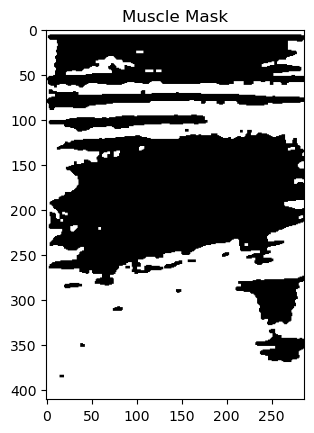

34.454984375323356


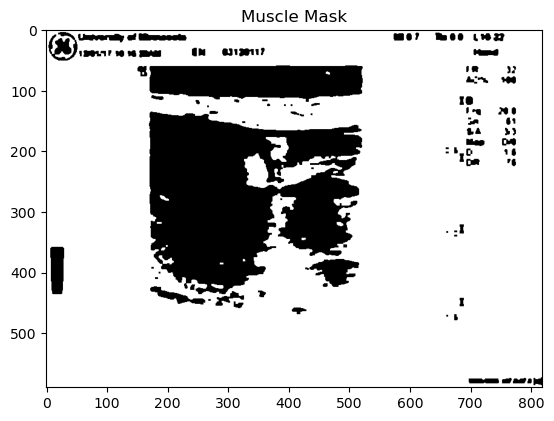

30.09793464539227


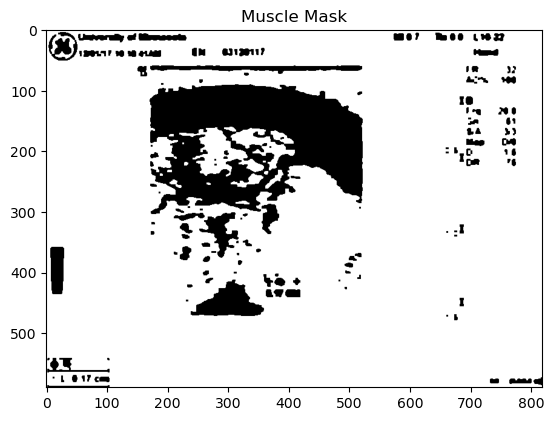

In [29]:
import cv2
import numpy as np

def mask(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print("Error: Image not loaded. Check the path.")
        return
    
    mean_intensity = np.mean(image)
    print('before process',mean_intensity)
    image = cv2.GaussianBlur(image, (7, 7), 0)

    if mean_intensity <35:
        _, mask = cv2.threshold(image, 75, 255, cv2.THRESH_BINARY_INV)
    else:
        _, mask = cv2.threshold(image, mean_intensity-10, 255, cv2.THRESH_BINARY_INV)


    if mean_intensity <35:
        image = cv2.medianBlur(image,11)
        image = cv2.bilateralFilter(image,29,75,75)
        _, mask = cv2.threshold(image, 75, 255, cv2.THRESH_BINARY_INV)
    else:
        image = cv2.GaussianBlur(image, (9, 9), 0)
        image = cv2.medianBlur(image,5)
        _, mask = cv2.threshold(image, mean_intensity-10, 255, cv2.THRESH_BINARY_INV)



        
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # Remove noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # Close small holes
    
    plt.imshow(mask, cmap='gray')
    plt.title('Muscle Mask')
    plt.show()

mask('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg')
mask('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/clinical_data/UM/03120117/03120117_AB1_R.jpg')
mask('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/clinical_data/UM/03120117/3120117_QUAD1_R.jpg')


before process 51.467170240002716


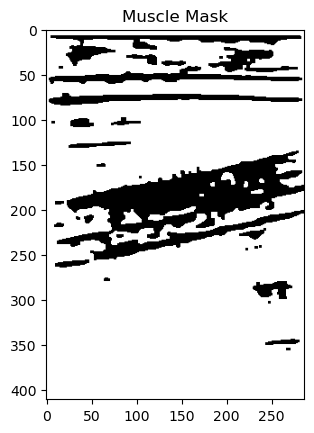

before process 34.454984375323356


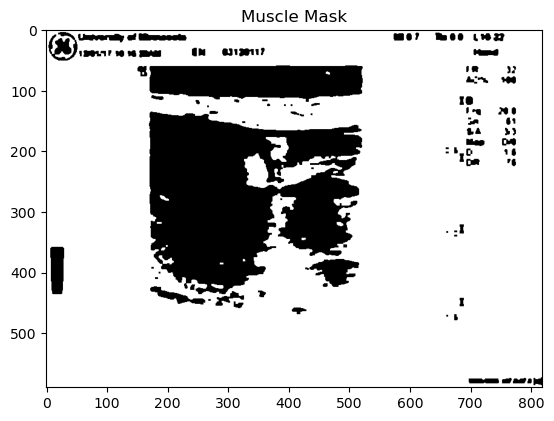

before process 30.09793464539227


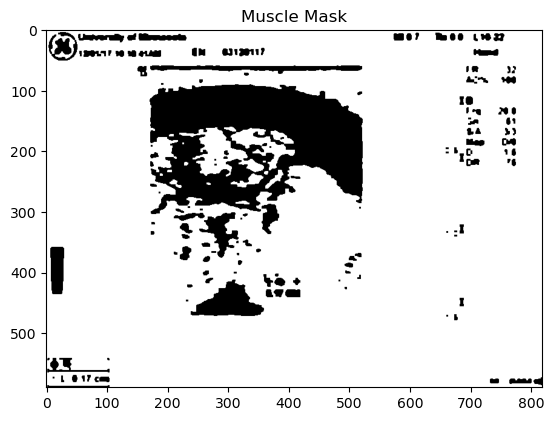

In [129]:
import cv2
import numpy as np

def mask(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print("Error: Image not loaded. Check the path.")
        return
    
    mean_intensity = np.mean(image)
    print('before process',mean_intensity)
    image = cv2.GaussianBlur(image, (7, 7), 0)

    _, mask = cv2.threshold(image, 75, 255, cv2.THRESH_BINARY_INV)





        
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # Remove noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # Close small holes
    
    plt.imshow(mask, cmap='gray')
    plt.title('Muscle Mask')
    plt.show()

mask('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg')
mask('../clinical_data/UM/03120117/03120117_AB1_R.jpg')
mask('../clinical_data/UM/03120117/3120117_QUAD1_R.jpg')
